# Seq2Seq 으로 번역기 만들기

In [1]:
!sudo apt update
!sudo apt-get install -y fonts-nanum
!pip install sentencepiece

Get:1 http://archive.ubuntu.com/ubuntu noble InRelease [256 kB]
Get:2 http://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]
Get:3 http://security.ubuntu.com/ubuntu noble-security/restricted amd64 Packages [3595 kB]
Get:4 http://security.ubuntu.com/ubuntu noble-security/main amd64 Packages [2030 kB]
Get:5 http://security.ubuntu.com/ubuntu noble-security/universe amd64 Packages [1500 kB]
Get:6 http://security.ubuntu.com/ubuntu noble-security/multiverse amd64 Packages [34.2 kB]
Get:7 http://archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]        
Get:8 http://archive.ubuntu.com/ubuntu noble-backports InRelease [126 kB]
Get:9 http://archive.ubuntu.com/ubuntu noble/multiverse amd64 Packages [331 kB]
Get:10 http://archive.ubuntu.com/ubuntu noble/restricted amd64 Packages [117 kB]
Get:11 http://archive.ubuntu.com/ubuntu noble/universe amd64 Packages [19.3 MB]
Get:12 http://archive.ubuntu.com/ubuntu noble/main amd64 Packages [1808 kB]
Get:13 http://archive.ubuntu.com/ub

In [5]:
!cp /usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf ./fonts/NanumBarunGothic.ttf

In [6]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

fontpath = "./fonts/NanumBarunGothic.ttf"
fontprop = fm.FontProperties(fname=fontpath, size=12)
plt.rcParams["font.family"] = fontprop.get_name()

print(f"설정된 폰트: {fontprop.get_name()}")

설정된 폰트: NanumBarunGothic


# 2. 데이터 전처리

In [3]:
import os
import re
import urllib.request
import zipfile
import sentencepiece as spm
import pandas as pd

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

from tqdm import tqdm
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.__version__)

2.7.1+cu118


- 데이터를 다운로드하는 데에는 urllib.request.urlretrieve() 함수를 사용할 겁니다.
- urllib.request.urlretrieve()함수는 URL로부터 데이터를 다운받고, zip_ref.extractall() 함수는 폴더 내 압축된 파일들을 찾아 해제까지 알아서 할 수 있는 똑똑한 함수랍니다!
- 아래 소스를 실행해 데이터를 다운로드받아주세요.

In [7]:
dataset_dir = os.path.expanduser("./s2s_translation/datasets")
os.makedirs(dataset_dir, exist_ok=True)

zip_path = os.path.join(dataset_dir, "spa-eng.zip")

if not os.path.exists(zip_path):
    print("데이터 다운로드 중...")
    url = "http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip"
    urllib.request.urlretrieve(url, zip_path)
    print("다운로드 완료!")

data_folder = os.path.join(dataset_dir, "spa-eng")
if not os.path.exists(data_folder):
    print("압축 해제 중...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(dataset_dir)
    print("압축 해제 완료!")

path_to_file = os.path.join(data_folder, "spa.txt")

print("데이터셋 디렉토리:", os.listdir(dataset_dir))

데이터 다운로드 중...
다운로드 완료!
압축 해제 중...
압축 해제 완료!
데이터셋 디렉토리: ['spa-eng', 'spa-eng.zip']


In [8]:
df = pd.read_csv(path_to_file, sep = "\t", names = ["eng", "spa"])
df.head()

,eng,spa
0,Go.,Ve.
1,Go.,Vete.
2,Go.,Vaya.
3,Go.,Váyase.
4,Hi.,Hola.


## 2-1 데이터 전처리: 정제하기

데이터는 \t 기호를 기준으로 영어와 스페인어가 병렬 쌍을 이루고 있습니다. 고로 \t 기호를 매개변수로 split() 함수를 호출하면 손쉽게 소스 문장과 타겟 문장을 분리할 수 있겠죠! 추가로 위 예시의 네 번째 문장을 보면 ¡ 같은 요상한 기호가 포함되어 있곤 합니다. 이 같은 특수문자는 불필요한 노이즈로 작용할 수 있기 때문에 정제 과정에서 삭제하도록 하겠습니다.

사실 스페인에서는 역 물음표(¿)와 역 느낌표(¡)를 일반적으로 사용합니다. 문장이 물음표나 느낌표로 끝난다면 해당 문장 맨 앞에 역으로 된 기호를 붙여준다고 해요. 이해를 돕기 위해 이상한 기호 취급을 하였으니 양해를 바랍니다!

$$함수를 사용할경우$$
" Hello World "
↓
"hello world"

In [11]:
def preprocess_sentence(sentence):
    sentence = sentence.lower().strip()

    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = re.sub(r"[^a-zA-Z?.!,]+", " ", sentence)

    sentence = sentence.strip()

    return sentence

print("슝~")

슝~


전처리 과정에서 문장의 시작 문자 <start>, 종료 문자 <end> 를 붙여주게 됩니다. 이 작업은 Encoder에 들어갈 입력 문장의 전처리에는 굳이 필요하지 않지만, Decoder의 입력 문장과 라벨로 사용할 출력 문장에는 꼭 필요하게 됩니다. 이전 렉처 노드에서 살펴보았듯, Decoder는 첫 입력으로 사용할 시작 토큰과 문장생성 종료를 알리는 끝 토큰이 반드시 필요하기 때문입니다.

원활한 학습을 위해 $데이터는 상위 3만개$만 사용하도록 하겠습니다.

In [12]:
df = df[:30000]

df["eng"] = df["eng"].apply(preprocess_sentence)
df["spa"] = df["spa"].apply(lambda x: preprocess_sentence(x))

df.head()

,eng,spa
0,go .,ve .
1,go .,vete .
2,go .,vaya .
3,go .,v yase .
4,hi .,hola .


## 2-2 데이터 전처리: 토큰화

SentencePiece를 사용하려면 텍스트 파일이 필요합니다. 먼저 SentencePiece를 활용해 Tokenizer를 생성하고 테이터를 변환하겠습니다. 변환된 텐서를 80%의 훈련 데이터와 20%의 검증 데이터로 분리하세요! (Tokenizer의 단어 수는 자유롭게 진행하세요!)

In [13]:
df["eng"].to_csv("eng_corpus.txt", index=False, header=False, sep="\n", encoding="utf-8")
df["spa"].to_csv("spa_corpus.txt", index=False, header=False, sep="\n", encoding="utf-8")

print("파일 저장 완료: eng_corpus.txt, spa_corpus.txt")

파일 저장 완료: eng_corpus.txt, spa_corpus.txt


In [14]:
vocab_size = 3000
pad_id = 0
bos_id = 1
eos_id = 2
unk_id = 3

spm.SentencePieceTrainer.train(
    input = "eng_corpus.txt",
    model_prefix = "encoder_spm",
    vocab_size = vocab_size,
    pad_id = pad_id,
    bos_id = bos_id,
    eos_id = eos_id,
    unk_id = unk_id
)

spm.SentencePieceTrainer.train(
    input = "spa_corpus.txt",
    model_prefix = "decoder_spm",
    vocab_size = vocab_size,
    pad_id = pad_id,
    bos_id = bos_id,
    eos_id = eos_id,
    unk_id = unk_id
)

sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: eng_corpus.txt
  input_format: 
  model_prefix: encoder_spm
  model_type: UNIGRAM
  vocab_size: 3000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  d

In [15]:
encoder_tokenizer = spm.SentencePieceProcessor()
encoder_tokenizer.load("encoder_spm.model")

decoder_tokenizer = spm.SentencePieceProcessor()
decoder_tokenizer.load("decoder_spm.model")

True

SentencePiece는 디코딩 과정에서 START_TOKEN과 END_TOKEN을 자동으로 변환해줍니다.

In [16]:
df

,eng,spa
0,go .,ve .
1,go .,vete .
2,go .,vaya .
3,go .,v yase .
4,hi .,hola .
...,...,...
29995,we ll go after we eat .,iremos despu s de comer .
29996,we ll live like kings .,viviremos como reyes .
29997,we ll lose everything .,lo perderemos todo .
29998,we ll meet right here .,nos encontraremos aqu mismo .


데이터 확인

In [17]:
eng_sample = df["eng"][10000]
spa_sample = df["spa"][10000]
print(eng_sample)
print(spa_sample)

do you like fish ?
te gusta el pescado ?


### 문장을 인코딩한 뒤 START_TOKEN과 END_TOKEN을 붙여주겠습니다.

In [18]:
enc_token = encoder_tokenizer.encode(eng_sample)
enc_token = [encoder_tokenizer.bos_id()] + enc_token + [encoder_tokenizer.eos_id()]
enc_token

[1, 27, 7, 39, 324, 9, 2]

### 위 토큰을 디코딩하면 어떻게 될까요?

In [19]:
enc_decoding = encoder_tokenizer.decode(enc_token)
enc_decoding

'do you like fish ?'

### 토큰화되어있는걸 복원했더니 원래값 잘 나옴.

이처럼 디코딩 과정에선 START_TOKEN과 END_TOKEN 부분을 제외하고 디코딩을 합니다.

START_TOKEN과 END_TOKEN은 데이터셋을 생성하는 과정에서 추가해주도록 하겠습니다. 일반적으로 Padding 작업은 torch.nn.utils.rnn.pad_sequence와 같은 라이브러리를 사용하지만 여기에서는 과정을 좀 더 풀어서 보여드리도록 하겠습니다.

In [20]:
class TranslationDataset(Dataset):
    def __init__(self, data, encoder_tokenizer, decoder_tokenizer, max_len):
        self.data = data
        self.encoder_tokenizer = encoder_tokenizer
        self.decoder_tokenizer = decoder_tokenizer
        self.max_len = max_len
        self.pad_id = 0
        self.bos_id = 1
        self.eos_id = 2

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        src_text = self.data.iloc[idx]['eng']
        trg_text = self.data.iloc[idx]['spa']

        src_ids = self.encoder_tokenizer.encode(src_text)
        trg_ids = self.decoder_tokenizer.encode(trg_text)

        src_ids = src_ids[:self.max_len]

        # Decoder의 입력에는 START_TOKEN과 END_TOKEN을 추가해줍니다. 단, 최대 길이 제한을 적용시킵니다.
        trg_input = [self.bos_id] + trg_ids[:self.max_len - 2] + [self.eos_id]
        trg_label = trg_ids[:self.max_len - 1] + [self.eos_id]

        # 길이가 짧은 경우 PAD_TOKEN을 추가해줍니다.
        src_ids = src_ids + [self.pad_id] * (self.max_len - len(src_ids))
        trg_input = trg_input + [self.pad_id] * (self.max_len - len(trg_input))
        trg_label = trg_label + [self.pad_id] * (self.max_len - len(trg_label))

        return torch.tensor(src_ids, dtype=torch.long), torch.tensor(trg_input), torch.tensor(trg_label)

In [21]:
train_ratio = 0.8  # 전체 길이의 80%
MAX_LEN = 30 # 임의의 값
BATCH_SIZE = 64

train_data = df.sample(frac=train_ratio, random_state=42)  # 80% 훈련 데이터
valid_data = df.drop(train_data.index)

train_data.reset_index(drop=True, inplace=True)
valid_data.reset_index(drop=True, inplace=True)

train_data = TranslationDataset(train_data, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)
validation_data = TranslationDataset(valid_data, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
validation_loader = DataLoader(validation_data, batch_size=BATCH_SIZE, shuffle=False)

In [22]:
for src, trg_input, trg_label in train_loader:
    print(src.shape, trg_input.shape, trg_label.shape)
    break

torch.Size([64, 30]) torch.Size([64, 30]) torch.Size([64, 30])


## 3. 모델 설계

아래처럼 각각 1개의 GRU를 갖는 Encoder-Decoder 구조를 설계할 겁니다.

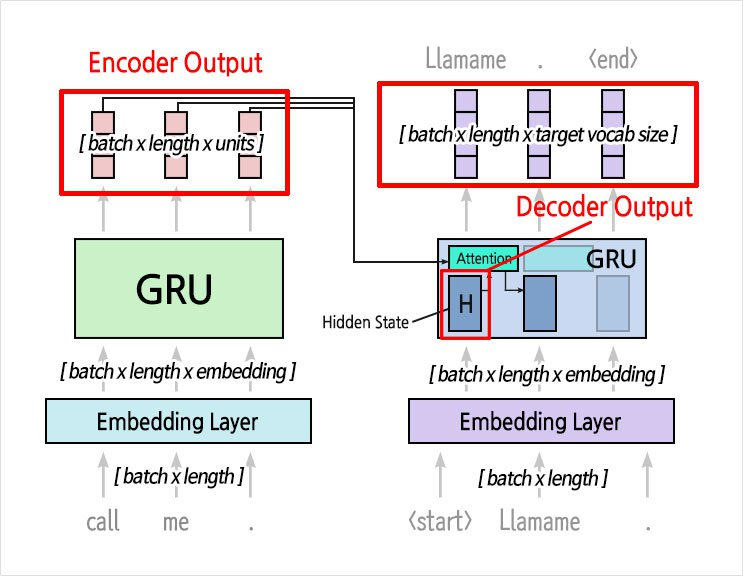

### 바다나우 어텐션

In [24]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch_size, hidden_dim)
        # encoder_outputs: (src_len, batch_size, hidden_dim)

        src_len = encoder_outputs.shape[0]

        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)  # (batch_size, src_len, hidden_dim)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # (batch_size, src_len, hidden_dim)

        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))  # (batch_size, src_len, hidden_dim)
        attention = self.v(energy).squeeze(2)  # (batch_size, src_len)

        return nn.functional.softmax(attention, dim=1)  # (batch_size, src_len)

### Encoder

In [37]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim, dropout=0.3):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.dropout = nn.Dropout(dropout)
        self.rnn = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src):
        # src : (src_len, batch_size)
        embedded = self.embedding(src)  # embedded : (src_len, batch_size, emb_dim)
        outputs, hidden = self.rnn(embedded)  # outputs : (src_len, batch_size, hidden_dim)

        return outputs, hidden

### Decoder

In [38]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention, dropout=0.3):
        super(Decoder, self).__init__()

        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.dropout = nn.Dropout(dropout)
        # Decoder RNN에는 embedding만 입력
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        # 출력층에는 hidden state와 attention value가 결합되어 입력
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        # input : (batch_size,)
        # hidden : (batch_size, hidden_dim)
        # encoder_outputs : (src_len, batch_size, hidden_dim)
        input = input.unsqueeze(0)  # input : (1, batch_size)
        # embedded = self.embedding(input)  # embedded : (1, batch_size, emb_dim)
        embedded = self.dropout(self.embedding(input)) # 드랍아웃 적용

        # attention distribution을 계산합니다. decoder의 이전 hidden state, s_{t-1}와 encoder의 H가 입력됩니다.
        a = self.attention(hidden[-1], encoder_outputs)  # a : (batch_size, src_len)

        # H에 가중치를 부여해 attention value(Context vector) 계산
        a = a.unsqueeze(1)  # a : (batch_size, 1, src_len)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # encoder_outputs : (batch_size, src_len, hidden_dim)
        context = torch.bmm(a, encoder_outputs)  # context : (batch_size, 1, hidden_dim)
        context = context.permute(1, 0, 2)  # context : (1, batch_size, hidden_dim)

        output, hidden = self.rnn(embedded, hidden)

        # 출력층에서는 현재 hidden state와 context vector를 결합하여 예측값 생성
        output = output.squeeze(0)  # output : (batch_size, hidden_dim)
        context = context.squeeze(0)  # context : (batch_size, hidden_dim)
        prediction = self.fc_out(torch.cat((output, context), dim=1))  # (batch_size, output_dim)

        return prediction, hidden, a.squeeze(1)

### Seq2SeqAttention

In [27]:
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=30, bos_id = 1, eos_id=2):
        # 학습 모드에서는 trg_len 사용, 추론 모드에서는 max_len까지 동적 생성
        batch_size = src.shape[1]
        trg_vocab_size = self.decoder.fc_out.out_features

        # 조기 종료를 위해 tensor가 아닌 리스트 사용
        outputs = []

        # 시각화를 위해 attention 저장
        attentions = []

        # 인코더를 통해 context 생성
        encoder_outputs, hidden = self.encoder(src)

        if trg is not None:
            for t in range(0, trg.shape[0]):
                input = trg[t]
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))

        else:
		    # inference에서는 target(정답)이 없기 때문에 sos_token을 생성해줍니다.
            input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)

            for t in range(max_len):
                output, hidden, attention = self.decoder(input, hidden,  encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                top1 = output.argmax(1)
                input = top1

                # 조기 종료 조건
                finished |= (top1 == eos_id)
                if finished.all():
                    break

        outputs = torch.cat(outputs, dim=0)  # (trg_len, batch_size, output_dim)
        attentions = torch.cat(attentions, dim=0)  # (trg_len, batch_size, src_len)

        return outputs, attentions

In [28]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

input_dim = len(encoder_tokenizer)
output_dim = len(decoder_tokenizer)
emb_dim = 256
hid_dim = 512

In [40]:
dropout = 0.3

encoder = Encoder(input_dim, emb_dim, hid_dim, dropout).to(device)
attention = BahdanauAttention(hid_dim).to(device)
decoder = Decoder(output_dim, emb_dim, hid_dim, attention, dropout).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)

In [41]:
print(model)

Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(3000, 256)
    (dropout): Dropout(p=0.3, inplace=False)
    (rnn): GRU(256, 512)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(3000, 256)
    (dropout): Dropout(p=0.3, inplace=False)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=3000, bias=True)
  )
)


## 4. 훈련하기

지금까지는 Optimizer 안에 파라미터를 간편하게 입력했지만, Encoder-Decoder 구조의 경우 모델이 분리되어 파라미터를 각각 정의해줘야 합니다. 조금 불편하고 난감하게 다가올 수도 있지만 후에 더 멋진 연구를 하기 위한 발판이 되어 줄 테니 익숙해져 봅시다!

낯선 함수들이 지나치게 많이 등장할 수 있으니, 이번 코스에선 직접 구현을 하기보단 구현체를 먼저 보고 이해하는 방향으로 공부하도록 합시다!

### (1) Optimizer & Loss

가장 큰 줄기를 먼저 보고, 점점 더 들어가 보는 방식으로 진행해볼게요. 첫 순서는 Optimizer와 Loss입니다!

In [42]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)

print("슝~")

슝~


### (2) Train_step

train_step()은 학습에 필요한 것을 모두 가져가 Loss를 계산한 후 반환하는 함수입니다. 먼저 구성을 보시죠!

In [43]:
def train_step(model, data_loader, optimizer, criterion, epoch):
    model.train()
    epoch_loss = 0

    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    for src, trg_input, trg_label in progress_bar:
        # 모델의 입력 순서에 맞게 transpose 변환
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)
        optimizer.zero_grad()

        outputs,_ = model(src, trg_input)
        
        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

        optimizer.step()

        epoch_loss += loss.item()

        progress_bar.set_postfix(loss=loss.item())

    return epoch_loss / len(data_loader)

print("슝~")


슝~


코드를 좀 더 자세히 살펴봅시다.

train_step()의 학습 과정은 아래와 같습니다.

1. model.train()을 호출하여 모델을 학습 모드로 전환합니다.
2. optimizer.zero_grad()를 통해 이전 배치에서 계산된 기울기를 초기화합니다.
3. Encoder에 소스 문장을 전달해 컨텍스트 벡터인 enc_out 을 생성
4. t=0일 때, Decoder의 Hidden State는 Encoder의 Final State로 정의. h_dec = enc_hidden Encoder 처리
5. <start> 문장과 enc_out, Hidden State를 기반으로 다음 단어(t=1)를 예측. predictions
6. 예측된 단어와 정답 간의 Loss를 구한 후, t=1의 정답 단어를 다음 입력으로 사용 (예측 단어 사용X)
7. 반복!

### Eval_step

In [36]:
def eval_step(model, data_loader, criterion):
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for src, trg_input, trg_label in data_loader:
            src = src.permute(1, 0).to(device)
            trg_input = trg_input.permute(1, 0).to(device)
            trg_label = trg_label.permute(1, 0).to(device)

            outputs, _ = model(src, trg_input)

            outputs = outputs.reshape(-1, outputs.shape[-1])
            trg_label = trg_label.reshape(-1)

            loss = criterion(outputs, trg_label)
            epoch_loss += loss.item()

    return epoch_loss / len(data_loader)


## Early Stopping 적용한 학습

In [44]:
%%time

EPOCHS = 20
patience = 3

best_valid_loss = float("inf")
patience_count = 0
best_model_state = None

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    valid_loss = eval_step(model, validation_loader, criterion)

    print(
        f"Epoch {epoch+1}/{EPOCHS}, "
        f"Train Loss: {train_loss:.4f}, "
        f"Validation Loss: {valid_loss:.4f}"
    )

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        patience_count = 0
        best_model_state = {
            key: value.cpu().clone()
            for key, value in model.state_dict().items()
        }
    else:
        patience_count += 1

    if patience_count >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

if best_model_state is not None:
    model.load_state_dict({
        key: value.to(device)
        for key, value in best_model_state.items()
    })


Epoch 1: 100%|██████████| 375/375 [00:42<00:00,  8.81it/s, loss=2.24]


Epoch 1/20, Train Loss: 3.1971, Validation Loss: 2.2017


Epoch 2: 100%|██████████| 375/375 [00:42<00:00,  8.92it/s, loss=1.45]


Epoch 2/20, Train Loss: 1.6845, Validation Loss: 1.6853


Epoch 3: 100%|██████████| 375/375 [00:42<00:00,  8.89it/s, loss=0.986]


...

Epoch 5/20, Train Loss: 0.5387, Validation Loss: 1.5520


Epoch 6: 100%|██████████| 375/375 [00:42<00:00,  8.92it/s, loss=0.631]


Epoch 6/20, Train Loss: 0.4068, Validation Loss: 1.5949


Epoch 7: 100%|██████████| 375/375 [00:42<00:00,  8.92it/s, loss=0.444]


Epoch 7/20, Train Loss: 0.3262, Validation Loss: 1.6348
Early stopping at epoch 7
CPU times: user 5min 20s, sys: 5.44 s, total: 5min 26s
Wall time: 5min 22s


### (6) 평가하기

In [45]:
def evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=30):
    model.eval()

    sentence = preprocess_sentence(sentence)
    src_ids = encoder_tokenizer.encode(sentence)
    src_ids = src_ids[:max_len]
    src_ids = src_ids + [0] * (max_len - len(src_ids))  # 패딩 추가
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)  # (src_len, 1)

    with torch.no_grad():
        outputs, attentions = model(src_tensor, max_len=max_len)

    result = [decoder_tokenizer.decode([token.item()]) for token in outputs.argmax(2).squeeze(1)]

    if "<end>" in result:
        result = result[:result.index("<end>")]

    return result, sentence, attentions.squeeze(1).cpu().numpy()

In [46]:
def plot_attention(attention, sentence, predicted_sentence):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.matshow(attention, cmap='viridis')

    fontdict = {'fontsize': 14}

    ax.set_xticks(range(len(sentence)))
    ax.set_xticklabels(sentence, fontdict=fontdict, rotation=90)

    ax.set_yticks(range(len(predicted_sentence)))
    ax.set_yticklabels(predicted_sentence, fontdict=fontdict)

    plt.show()

In [47]:
def translate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=30):
    result, sentence, attention = evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len)

    print('Input: %s' % (sentence))
    print('Predicted translation: {}'.format(result))

    # Attention 크기 조정 (trg_len, src_len)
    attention = attention[:len(result), :len(sentence.split())]

    plot_attention(attention, sentence.split(), result)

Input: the most powerful man all over the world .
Predicted translation: ['el', 'hombre', 'se', 'h', 'izo', 'el', 'ment', 'o', '.', '']


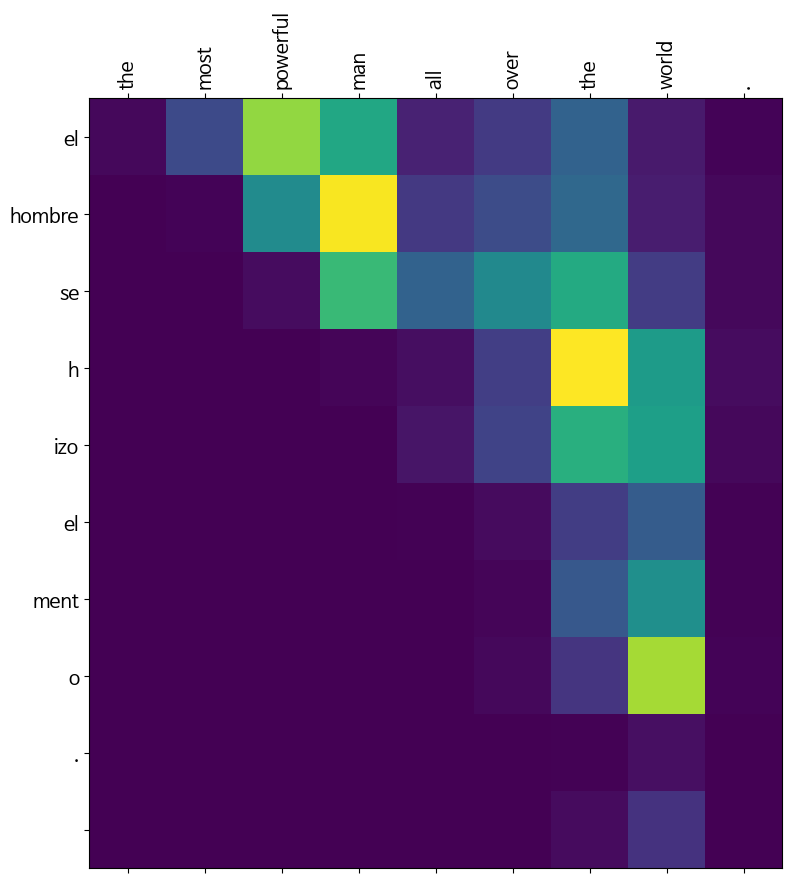

In [48]:
translate("The most powerful man all over the world.", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: may i help you ?
Predicted translation: ['pued', 'o', 'ayudar', 'te', '?', '']


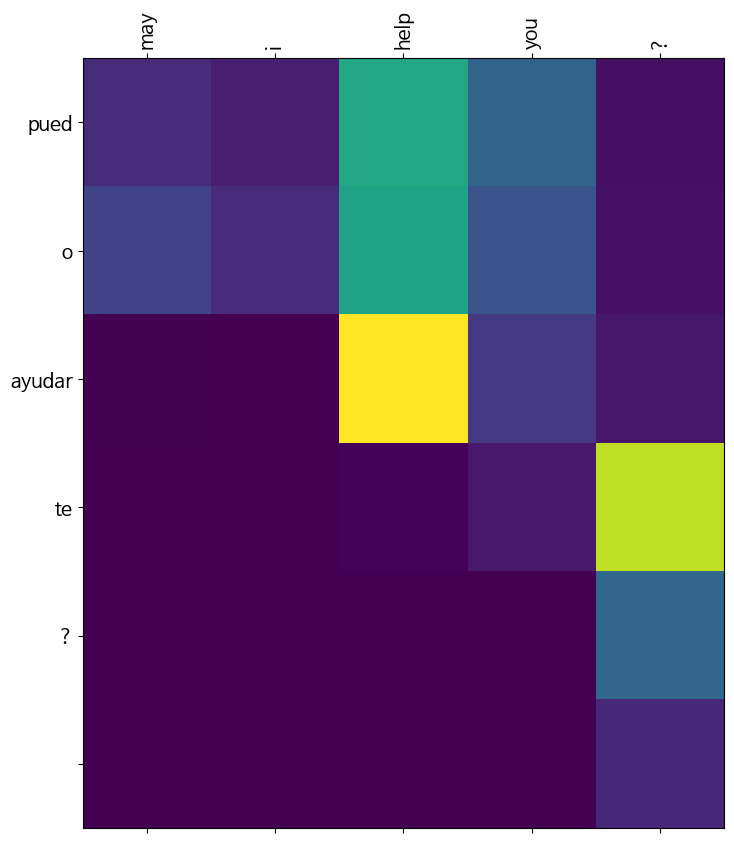

In [49]:
translate("May I help you?", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: can i have some coffee ?
Predicted translation: ['pued', 'o', 'tomar', 'me', 'algo', '?', '']


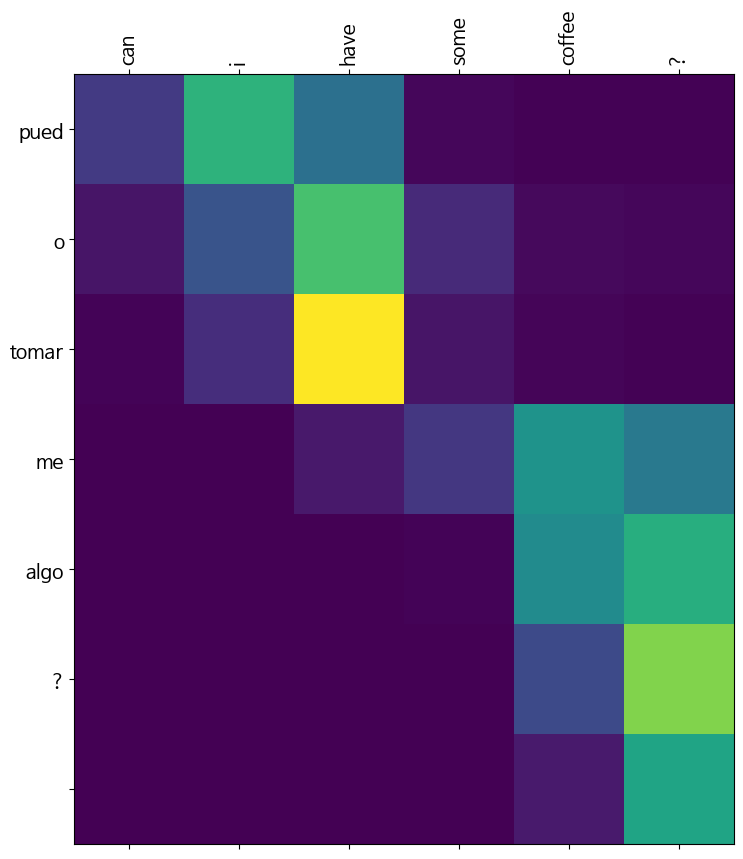

In [50]:
# 실행 예제
translate("Can I have some coffee?", model, encoder_tokenizer, decoder_tokenizer, max_len=30)